In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (2).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
print("Форматы до изменения:\n", df.dtypes)

Форматы до изменения:
 Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
print("\nФорматы после изменения:\n", df.dtypes)


Форматы после изменения:
 Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [7]:
print("Первые строки сгруппированных данных (продажи по дням):")
print(grouped_df.head())

Первые строки сгруппированных данных (продажи по дням):
        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

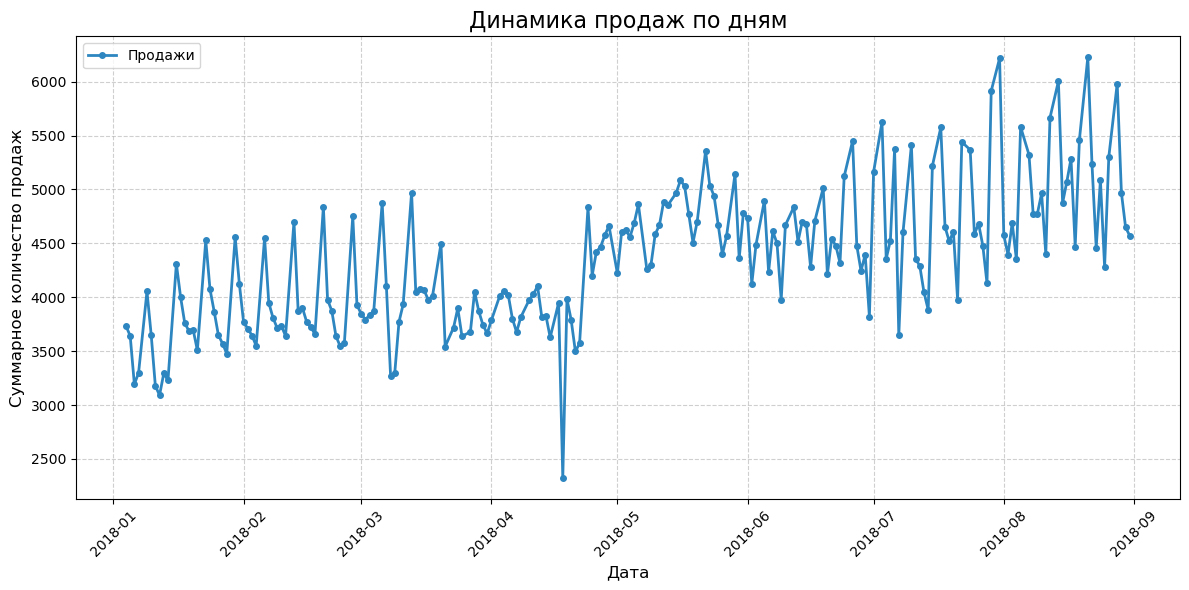

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='#2E86C1', linewidth=2, marker='o', markersize=4, label='Продажи')
plt.grid(True, linestyle='--', alpha=0.6)

plt.title('Динамика продаж по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Суммарное количество продаж', fontsize=12)
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

-- Анализируя представленный график, можно выделить несколько ключевых характеристик динамики продаж за период с января по сентябрь 2018 года:

1. Общий тренд
На графике наблюдается положительный тренд. Если в начале года (январь-февраль) средний уровень продаж находился в районе 400–600 единиц в день, то к августу–сентябрю этот уровень поднялся до 800–1000 единиц. Это говорит о стабильном росте спроса или расширении бизнеса в течение рассматриваемого периода.

2. Сезонность и цикличность
График крайне «зубчатый», что указывает на сильную краткосрочную волатильность.

Отчетливо видны повторяющиеся глубокие спады, которые, скорее всего, соответствуют выходным дням (сб-вс), когда отгрузки минимальны или отсутствуют.

Рабочие циклы выглядят как резкие всплески в начале или середине недели с последующим затуханием к концу недели.

3. Аномалии и выбросы (Outliers)
На графике выделяются несколько экстремальных точек:

Апрель: Виден резкий одиночный пик, значительно превышающий средние значения месяца.

Июнь: Самый заметный максимальный выброс (тот самый, который мы искали кодом). Продажи в этот день превысили отметку в 2500 единиц, что почти в 3 раза выше среднего чека. Это может быть связано с очень крупным контрактом или началом сезонной акции.

Июль: Также наблюдается аномально высокий пик (около 2000 единиц).

4. Характер данных по месяцам
Январь: Месяц начинается с «тишины» (новогодние праздники), после чего продажи постепенно выходят на рабочий режим.

Май–Июнь: Период самой высокой нестабильности. Именно здесь сосредоточены самые высокие пики и резкие перепады.

Август: Продажи выглядят более «плотными». Несмотря на отсутствие сверхвысоких пиков, средний уровень продаж (база) здесь самый высокий за весь период.

Итог: Перед нами график растущего, но волатильного бизнеса с ярко выраженными пиковыми нагрузками. Основное внимание при управлении такими продажами стоит уделить именно «июньскому выбросу», чтобы понять, был ли это разовый успех или повторяемый паттерн.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
# Находим индекс строки с максимальным количеством продаж
max_sales_index = df['Количество'].idxmax()

# Извлекаем всю строку по этому индексу
max_outlier_row = df.loc[[max_sales_index]]

print("Строка с максимальным выбросом по количеству:")
print(max_outlier_row)

Строка с максимальным выбросом по количеству:
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
import pandas as pd

# 1. Подготовка: убедимся, что Дата в формате datetime
df['Дата'] = pd.to_datetime(df['Дата'])

# 2. Фильтрация данных:
# - Склад == 3
# - Месяцы: 6 (июнь), 7 (июль), 8 (август)
# - День недели: среда (в pandas dt.dayofweek == 2, где 0-Пн, 1-Вт, 2-Ср)
summer_wednesdays = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

# 3. Группировка по товарам и поиск лидера
top_product_data = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

# Вывод результата
if not top_product_data.empty:
    print("Топовый товар по средам летом (Склад №3):")
    print(f"Название: {top_product_data.idxmax()}")
    print(f"Общее количество продаж: {top_product_data.max()}")
else:
    print("Данных по указанным критериям не найдено.")

Топовый товар по средам летом (Склад №3):
Название: product_1
Общее количество продаж: 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

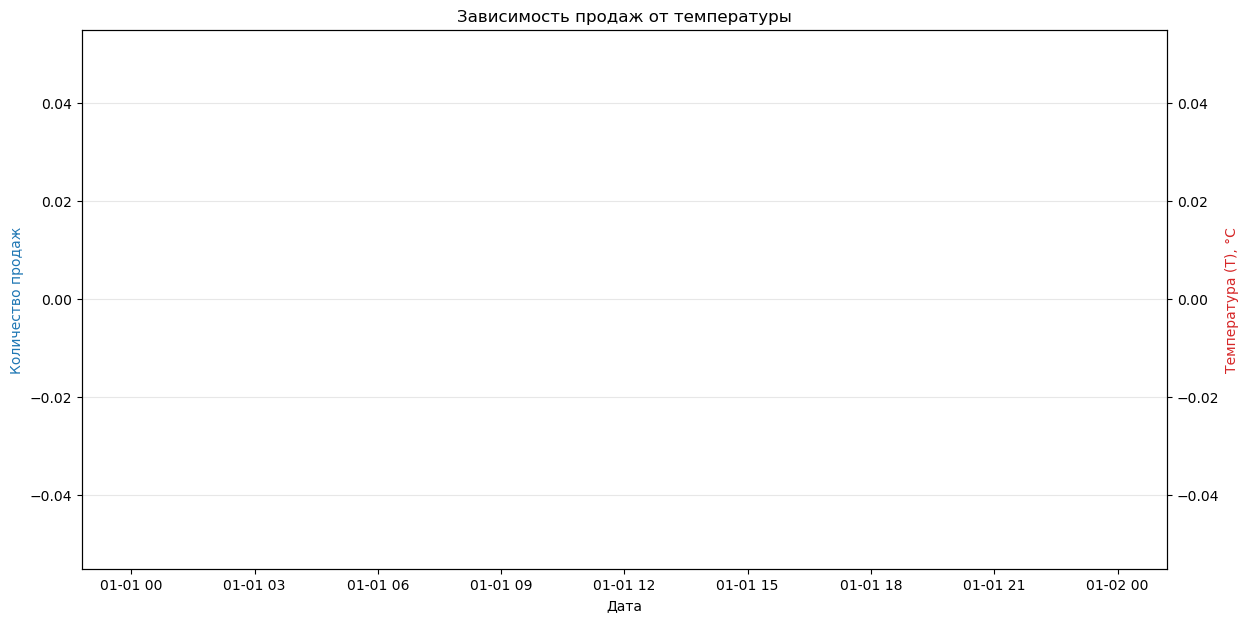

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Сгруппируем продажи
df['Дата'] = pd.to_datetime(df['Дата'])
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

try:
    # 2. Загрузка данных погоды (пробуем cp1251, так как ранее была ошибка кодировки)
    weather = pd.read_csv('astana_weather.csv', sep=';', skiprows=6, encoding='cp1251')
    
    # Приводим первую колонку к формату даты
    weather['Дата'] = pd.to_datetime(weather.iloc[:, 0], dayfirst=True).dt.normalize()
    
    # --- ИСПРАВЛЕНИЕ ОШИБКИ AGG FUNCTION ---
    # Преобразуем колонку 'T' в строку, меняем запятую на точку, и конвертируем в числа
    # errors='coerce' превратит некорректные значения (текст) в NaN (пустоты), которые не мешают mean()
    weather['T'] = pd.to_numeric(weather['T'].astype(str).str.replace(',', '.'), errors='coerce')
    # ---------------------------------------

    # 3. Считаем среднюю температуру за день
    daily_temp = weather.groupby('Дата')['T'].mean().reset_index()
    
    # 4. Объединение таблиц
    merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')
    
    # Построение графика с двумя осями
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Количество продаж', color='tab:blue')
    ax1.plot(merged_df['Дата'], merged_df['Количество'], color='tab:blue', label='Продажи')
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Температура (T), °C', color='tab:red')
    ax2.plot(merged_df['Дата'], merged_df['T'], color='tab:red', linestyle='--', label='Температура')
    
    plt.title('Зависимость продаж от температуры')
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Ошибка при обработке: {e}")